## Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import json
import csv
import requests
import joblib
import os
from io import StringIO
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier


In [14]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [ ]:
dataset = pd.read_csv('dataset/review_app_brimo.csv')
dataset.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8b8b79fc-58d7-40d4-bde8-397010fbfa5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah mantap... tetapi kok susah dilanjutkan j...,5,0,2.95.1,2026-04-29 11:08:51,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-27 22:23:05,2.95.1
1,ebe3c116-749f-44fa-9354-f56d86f6e556,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas sekali,5,0,2.95.1,2026-04-29 11:06:53,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-04-29 11:30:17,2.95.1
2,a534f6d5-bc7b-447f-bcc6-dda7f03f2a4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terbaik👍🏻,5,0,NaN,2026-04-29 11:02:37,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 11:31:00,NaN
3,6fd32a26-25f1-4b5b-a1d8-04fa32f6f90a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,2.95.1,2026-04-29 10:48:36,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:17,2.95.1
4,0bd6f0c1-0fe6-4818-894c-068d07ef58c6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat nyaman menggunakan BRI 👍👍,5,0,2.95.1,2026-04-29 10:46:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:11,2.95.1


In [16]:
# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = dataset.shape

print(jumlah_ulasan)
print(jumlah_kolom)

50000
11


In [17]:
# Menampilkan informasi dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              50000 non-null  object
 1   userName              50000 non-null  object
 2   userImage             50000 non-null  object
 3   content               50000 non-null  object
 4   score                 50000 non-null  int64 
 5   thumbsUpCount         50000 non-null  int64 
 6   reviewCreatedVersion  40730 non-null  object
 7   at                    50000 non-null  object
 8   replyContent          49646 non-null  object
 9   repliedAt             49646 non-null  object
 10  appVersion            40730 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.2+ MB


## Preprocessing

#### Data Cleaning

In [18]:
# Mengecek nilai kosong pada dataset
dataset.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    9270
at                         0
replyContent             354
repliedAt                354
appVersion              9270
dtype: int64

In [19]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN)  dari dataset
clean_df = dataset.dropna()

#Menghapus data yang duplikat dari dataset
clean_df.drop_duplicates()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8b8b79fc-58d7-40d4-bde8-397010fbfa5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah mantap... tetapi kok susah dilanjutkan j...,5,0,2.95.1,2026-04-29 11:08:51,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-27 22:23:05,2.95.1
1,ebe3c116-749f-44fa-9354-f56d86f6e556,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas sekali,5,0,2.95.1,2026-04-29 11:06:53,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-04-29 11:30:17,2.95.1
3,6fd32a26-25f1-4b5b-a1d8-04fa32f6f90a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,2.95.1,2026-04-29 10:48:36,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:17,2.95.1
4,0bd6f0c1-0fe6-4818-894c-068d07ef58c6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat nyaman menggunakan BRI 👍👍,5,0,2.95.1,2026-04-29 10:46:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:11,2.95.1
5,d8d37489-77e2-4300-a4da-deef2ceed022,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot gk bisa daftar padahal udah langkah tera...,1,0,2.95.1,2026-04-29 10:46:04,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-04-29 11:01:32,2.95.1
...,...,...,...,...,...,...,...,...,...,...,...
49994,7483de5a-2d38-4e03-b61f-bbd4968c2c11,Ady Tia,https://play-lh.googleusercontent.com/a-/ALV-U...,trimakasih brimo,5,0,2.88.1,2025-10-21 15:15:40,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2025-10-21 15:48:59,2.88.1
49995,20bf25e2-168a-497e-b9f7-244d11120775,fauzan sanz,https://play-lh.googleusercontent.com/a-/ALV-U...,gak bisa tf,1,0,2.88.1,2025-10-21 15:10:19,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2025-10-21 15:50:29,2.88.1
49996,e338971d-1735-4062-9757-8c83077f49bf,Tanti Mulyanioktaviani,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus,5,0,2.88.1,2025-10-21 15:05:07,"Hai Sobat BRI, terima kasih atas ulasannya 🙏. ...",2025-10-21 15:23:11,2.88.1
49998,ba129583-830c-4f40-b727-c1cb69eb3fe4,Sakti Eko,https://play-lh.googleusercontent.com/a/ACg8oc...,top,5,0,2.88.1,2025-10-21 14:57:39,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2025-10-21 15:26:00,2.88.1


In [20]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40449 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              40449 non-null  object
 1   userName              40449 non-null  object
 2   userImage             40449 non-null  object
 3   content               40449 non-null  object
 4   score                 40449 non-null  int64 
 5   thumbsUpCount         40449 non-null  int64 
 6   reviewCreatedVersion  40449 non-null  object
 7   at                    40449 non-null  object
 8   replyContent          40449 non-null  object
 9   repliedAt             40449 non-null  object
 10  appVersion            40449 non-null  object
dtypes: int64(2), object(9)
memory usage: 3.7+ MB


In [21]:
# Fungsi untuk membersihkan teks dari simbol, angka, dll
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) 
    text = re.sub(r'#[A-Za-z0-9]+', '', text) 
    text = re.sub(r'RT[\s]', '', text) 
    text = re.sub(r"http\S+", '', text) 
    text = re.sub(r'[0-9]+', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 


    text = text.replace('\n', ' ') 
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    text = text.strip(' ') #
    return text

# Fungsi untuk merubah semua karakter menjadi lower case
def casefoldingText(text): 
    text = text.lower()
    return text

# Fungsi untuk membagi teks menjadi token
def tokenizingText(text): 
    text = word_tokenize(text)
    return text

# Fungsi untuk memfilter stopwords
def filteringText(text): 
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text


# Fungsi untuk menggabungkan kata-kata menjadi kalimat
def toSentence(list_words): 
    sentence = ' '.join(word for word in list_words)
    return sentence

In [22]:
# Fungsi untuk menerapkan stemming pada teks
def stemmingText(text, stemmer_obj):
    return stemmer_obj.stem(text)

In [23]:
# Fungsi untuk memuat data JSON menjadi kamus 
def load_slangwords(filepath):
    with open(filepath, 'r', encoding='utf-8') as file:
        return json.load(file)


def fix_slangwords(text, slang_dict):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])

In [24]:
factory = StemmerFactory()
stemmer_sastrawi = factory.create_stemmer()
slangwords_dict = load_slangwords('dataset/slangwords.json')

# 1. Pembersihan teks awal
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# 2. Mengubah menjadi huruf kecil (case folding)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# 3. Memperbaiki kata slang menggunakan lambda
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(lambda x: fix_slangwords(x, slangwords_dict))

# 4. Tokenisasi
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# 5. Menghapus stopword
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# 6. Menggabungkan kembali menjadi kalimat
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# 7. Proses Stemming menggunakan lambda
clean_df['text_stemmed'] = clean_df['text_akhir'].apply(lambda x: stemmingText(x, stemmer_sastrawi))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23812\2612001588.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23812\2612001588.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23812\2612001588.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

In [47]:
clean_df.to_csv("dataset/clean_review_app_brimo.csv")

In [25]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,text_stemmed
0,8b8b79fc-58d7-40d4-bde8-397010fbfa5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah mantap... tetapi kok susah dilanjutkan j...,5,0,2.95.1,2026-04-29 11:08:51,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-27 22:23:05,2.95.1,sudah mantap tetapi kok susah dilanjutkan jika...,sudah mantap tetapi kok susah dilanjutkan jika...,sudah mantap tetapi kok susah dilanjutkan jika...,"[sudah, mantap, tetapi, kok, susah, dilanjutka...","[mantap, susah, dilanjutkan, mengisi, nama, ba...",mantap susah dilanjutkan mengisi nama bank nor...,mantap susah lanjut isi nama bank norek tuju t...
1,ebe3c116-749f-44fa-9354-f56d86f6e556,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas sekali,5,0,2.95.1,2026-04-29 11:06:53,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-04-29 11:30:17,2.95.1,sangat puas sekali,sangat puas sekali,sangat puas sekali,"[sangat, puas, sekali]",[puas],puas,puas
3,6fd32a26-25f1-4b5b-a1d8-04fa32f6f90a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,2.95.1,2026-04-29 10:48:36,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:17,2.95.1,good,good,good,[good],[good],good,good
4,0bd6f0c1-0fe6-4818-894c-068d07ef58c6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat nyaman menggunakan BRI 👍👍,5,0,2.95.1,2026-04-29 10:46:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-29 10:59:11,2.95.1,sangat nyaman menggunakan BRI,sangat nyaman menggunakan bri,sangat nyaman menggunakan bri,"[sangat, nyaman, menggunakan, bri]","[nyaman, bri]",nyaman bri,nyaman bri
5,d8d37489-77e2-4300-a4da-deef2ceed022,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot gk bisa daftar padahal udah langkah tera...,1,0,2.95.1,2026-04-29 10:46:04,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-04-29 11:01:32,2.95.1,lemot gk bisa daftar padahal udah langkah tera...,lemot gk bisa daftar padahal udah langkah tera...,lambat gk bisa daftar padahal sudah langkah te...,"[lambat, gk, bisa, daftar, padahal, sudah, lan...","[lambat, gk, daftar, langkah, error, kalimat, ...",lambat gk daftar langkah error kalimat transak...,lambat gk daftar langkah error kalimat transak...


In [26]:
def load_lexicon_from_github(url):
    lexicon_dict = {}
    
    try:
        response = requests.get(url)

        if response.status_code == 200:
            reader = csv.reader(StringIO(response.text), delimiter=',')
            
            for row in reader:
                if len(row) >= 2:
                    lexicon_dict[row[0]] = int(row[1])
                    
            return lexicon_dict
        else:
            print(f"Gagal mengunduh leksikon. Kode Status HTTP: {response.status_code} untuk URL: {url}")
            return {}
            
    except requests.exceptions.RequestException as e:
        print(f"Terjadi kesalahan koneksi jaringan: {e}")
        return {}

In [27]:
url_pos = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
url_neg = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'

lexicon_positive = load_lexicon_from_github(url_pos)
lexicon_negative = load_lexicon_from_github(url_neg)

# (Opsional) Memverifikasi jumlah kata yang berhasil dimuat
print(f"Total kata positif termuat : {len(lexicon_positive)}")
print(f"Total kata negatif termuat : {len(lexicon_negative)}")

Total kata positif termuat : 3609
Total kata negatif termuat : 6607


## Labeling Data

In [33]:
def sentiment_analysis_lexicon_indonesia(text, lex_positive, lex_negative):
    if isinstance(text, str):
        words = text.split()
    else:
        words = text
    score = 0
    for word in words:
        score += lex_positive.get(word, 0)
        score += lex_negative.get(word, 0) 
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'
    return score, polarity

In [34]:
results = clean_df['text_stopword'].apply(lambda x: sentiment_analysis_lexicon_indonesia(x, lexicon_positive, lexicon_negative))
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    18680
negative    11955
neutral      9814
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23812\3328536697.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['polarity_score'] = results[0]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23812\3328536697.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['polarity'] = results[1]


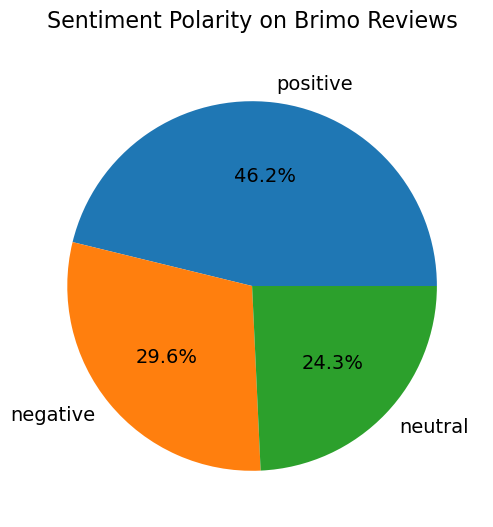

In [36]:

fig, ax = plt.subplots(figsize=(6, 6))

sizes = clean_df['polarity'].value_counts().tolist()
labels = clean_df['polarity'].value_counts().index.tolist()
explode = (0,0,0) 
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Brimo Reviews', fontsize=16, pad=20)
plt.show()

In [37]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,text_stemmed,polarity_score,polarity
0,8b8b79fc-58d7-40d4-bde8-397010fbfa5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah mantap... tetapi kok susah dilanjutkan j...,5,0,2.95.1,2026-04-29 11:08:51,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-27 22:23:05,2.95.1,sudah mantap tetapi kok susah dilanjutkan jika...,sudah mantap tetapi kok susah dilanjutkan jika...,sudah mantap tetapi kok susah dilanjutkan jika...,"[sudah, mantap, tetapi, kok, susah, dilanjutka...","[mantap, susah, dilanjutkan, mengisi, nama, ba...",mantap susah dilanjutkan mengisi nama bank nor...,mantap susah lanjut isi nama bank norek tuju t...,4,positive
1,ebe3c116-749f-44fa-9354-f56d86f6e556,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas sekali,5,0,2.95.1,2026-04-29 11:06:53,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-04-29 11:30:17,2.95.1,sangat puas sekali,sangat puas sekali,sangat puas sekali,"[sangat, puas, sekali]",[puas],puas,puas,3,positive


In [38]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

In [39]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [40]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,admin,akses,akun,alhamdulillah,aman,aneh,apapun,apk,aplikasi,aplikasinya,...,ulang,uninstal,update,urusan,username,verifikasi,versi,wajah,warna,wifi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
# Fungsi untuk melatih, mengevaluasi, dan menyimpan model machine learning.
def train_evaluate_save_model(model, model_name, X_train, X_test, y_train, y_test):
    
    # 1. Membuat folder model/nama_model jika belum ada
    folder_path = f'model/{model_name}'
    os.makedirs(folder_path, exist_ok=True)
    
    # 2. Menangani sparse matrix (menyesuaikan dengan kode asli Anda yang menggunakan .toarray())
    # Mengecek apakah X_train dan X_test memiliki metode toarray() (biasanya dari TF-IDF / CountVectorizer)
    X_train_arr = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
    X_test_arr = X_test.toarray() if hasattr(X_test, 'toarray') else X_test
    
    # 3. Melatih model pada data pelatihan
    model.fit(X_train_arr, y_train)
    
    # 4. Prediksi sentimen pada data pelatihan dan data uji
    y_pred_train = model.predict(X_train_arr)
    y_pred_test = model.predict(X_test_arr)
    
    # 5. Evaluasi akurasi model
    accuracy_train = accuracy_score(y_pred_train, y_train)
    accuracy_test = accuracy_score(y_pred_test, y_test)
    
    # 6. Menampilkan akurasi
    print(f'{model_name} - accuracy_train: {accuracy_train:.4f}')
    print(f'{model_name} - accuracy_test: {accuracy_test:.4f}')
    
    # 7. Menyimpan model ke dalam folder yang sudah dibuat
    model_path = os.path.join(folder_path, f'{model_name}.pkl')
    joblib.dump(model, model_path)
    print(f"Model berhasil disimpan di: {model_path}\n")
    
    return model

In [43]:


# 1. Menggunakan Naive Bayes
nb_model = BernoulliNB()
train_evaluate_save_model(
    model=nb_model, 
    model_name="Naive_Bayes", 
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test
)

--- Memulai proses untuk Naive_Bayes ---
Naive_Bayes - accuracy_train: 0.8632
Naive_Bayes - accuracy_test: 0.8564
Model berhasil disimpan di: model/Naive_Bayes\Naive_Bayes.pkl



,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [44]:
# 2. Menggunakan Random Forest
rf_model = RandomForestClassifier()
train_evaluate_save_model(
    model=rf_model, 
    model_name="Random_Forest", 
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test
)

--- Memulai proses untuk Random_Forest ---
Random_Forest - accuracy_train: 0.9662
Random_Forest - accuracy_test: 0.9119
Model berhasil disimpan di: model/Random_Forest\Random_Forest.pkl



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# 2. Menggunakan Random Forest
rf_model = LogisticRegression()
train_evaluate_save_model(
    model=rf_model, 
    model_name="Logistic_Regression", 
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test
)

--- Memulai proses untuk Logistic_Regression ---
Logistic_Regression - accuracy_train: 0.9231
Logistic_Regression - accuracy_test: 0.9230
Model berhasil disimpan di: model/Logistic_Regression\Logistic_Regression.pkl



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [46]:
# 2. Menggunakan Random Forest
rf_model = DecisionTreeClassifier()
train_evaluate_save_model(
    model=rf_model, 
    model_name="Decision_Tree_Classifer", 
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test
)

--- Memulai proses untuk Decision_Tree_Classifer ---
Decision_Tree_Classifer - accuracy_train: 0.9662
Decision_Tree_Classifer - accuracy_test: 0.8936
Model berhasil disimpan di: model/Decision_Tree_Classifer\Decision_Tree_Classifer.pkl



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None
